In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr

import sys
sys.path.append('..')
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

In [2]:
#data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = '../Camera_Calibrations/Ximea_Camera/'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [3]:
image_size = 20
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [39]:
n_photon_space = np.logspace(np.log10(500), np.log10(20000), 100)
n_bootstrap = 20000
background_photons = 20
pixel_size = 69
NA = 1.49

In [40]:
readnoises = np.array([0.5, 2.3, 5])
import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [41]:
dyes = ['ATTO 488', 'ATTO 565', 'ATTO 594', 'ATTO 647N']

In [42]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-635-t1-25x36'
nilered_filter = 'semrock-ff01-650-200-25'
shortpass_filter = 'semrock-bsp01-785r'
filters = [notch_filter, dichroic_mirror, shortpass_filter]

In [43]:
save_folder = r'/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250728_MultiDyes'
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

In [44]:
for dye in dyes:
    for readnoise in readnoises:
        camera_parameters["readnoise"] = np.full((image_size, image_size), readnoise)
        variance = np.square(np.median(gain)*readnoise)
        print(variance)
        camera_parameters["variance"] = np.full((image_size, image_size), variance)
        print("Analysing dye {}".format(dye), end="\r",flush=True,)        
        MSF.test_fit_method(
                                dye,
                                filters,
                                wavelength,
                                camera_parameters,
                                save_folder,
                                n_photon_space,
                                smoothing_function=smoothing_function,
                                starting_flag="variance_"+str(np.around(variance, 3)).replace('.', 'p')+"_simulation",
                                n_bootstrap=n_bootstrap,
                                background_photons=background_photons,
                                NA=NA,
                                pixel_size=pixel_size,
                                cpu_fraction=1,
                            )

0.04292710608589248


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 238.70task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 231.93task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 238.72task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 238.49task/s]

...


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 242.97task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 242.95task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 240.87task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 242.80task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 240.54task/s]

In [45]:
files = os.listdir(save_folder)

In [49]:
lowvar_RMSE = np.sort([os.path.join(save_folder, x) for x in files if 'RMSE_mean' in x and '0p043' in x])
highvar_RMSE = np.sort([os.path.join(save_folder, x) for x in files if 'RMSE_mean' in x and '0p908' not in x])

In [51]:
for i, file in enumerate(highvar_RMSE):
    if i == 0:
        highvar = pl.read_csv(file)
    else:
        highvar = highvar + pl.read_csv(file)
highvar = highvar/(i+1)

In [52]:
for i, file in enumerate(lowvar_RMSE):
    if i == 0:
        lowvar = pl.read_csv(file)
    else:
        lowvar = lowvar + pl.read_csv(file)
lowvar = lowvar/(i+1)

In [71]:
A = np.zeros([20, 20])

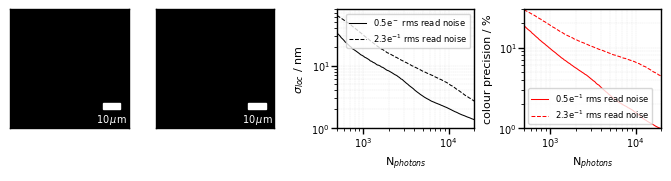

In [91]:
fig, axs = plotter.two_column_plot(ncolumns=4, widthratio=[1,1,1,1], height=1.7)

for i in np.arange(2):
    axs[i] = plotter.image_plot(axs[i], A, cbar='off', scalebarsize=200)

axs[2] = plotter.line_plot(axs[2], x=lowvar['n_photons'].to_numpy(), y=0.5*(lowvar['xc'].to_numpy()+lowvar['yc'].to_numpy()),
                          xaxislabel=r'N$_{photons}$', yaxislabel=r'$\sigma_{loc}$ / nm', label=r'0.5e$^-$ rms read noise')

axs[2] = plotter.line_plot(axs[2], x=highvar['n_photons'].to_numpy(), y=0.5*(highvar['xc'].to_numpy()+highvar['yc'].to_numpy()),
                          xaxislabel=r'N$_{photons}$', ls='--', yaxislabel=r'$\sigma_{loc}$ / nm', label='2.3e$^{-1}$ rms read noise')

axs[2].set_yscale('log')
axs[2].set_xscale('log')
axs[2].legend(loc='best', fontsize=6)


axs[3] = plotter.line_plot(axs[3], x=lowvar['n_photons'].to_numpy(), y=100*(lowvar['colour_distance'].to_numpy()),
                          xaxislabel=r'N$_{photons}$', color='red', yaxislabel='colour precision / %', label='0.5e$^{-1}$ rms read noise')

axs[3] = plotter.line_plot(axs[3], x=highvar['n_photons'].to_numpy(), y=100*(highvar['colour_distance'].to_numpy()),
                          xaxislabel=r'N$_{photons}$', ls='--', color='red', yaxislabel='colour precision / %', label='2.3e$^{-1}$ rms read noise')

axs[3].set_yscale('log')
axs[3].set_xscale('log')
axs[3].legend(loc='best', fontsize=6)

axs[2].set_xlim([500, 20000])
axs[3].set_xlim([500, 20000])
axs[3].set_ylim([1, 30])
axs[2].set_ylim([1, 80])

plt.savefig('example_info_theory.svg', dpi=600, format='svg')